In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.utils as utils
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)
        self.fc22 = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)


In [7]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

In [8]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.get_one_sample(mu, logvar)
        return self.decoder(z), mu, logvar

    def get_one_sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def sample(self, num_samples):
        with torch.no_grad():
            z = torch.randn(num_samples, self.encoder.fc21.out_features)
            return self.decoder(z)

In [9]:
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
    return BCE + KLD

In [10]:
epochs = 10
input_dim = 28 * 28
hidden_dim = 400
latent_dim = 20

model = VAE(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)


Epoch [1/10]  Avg Loss: 148.2818


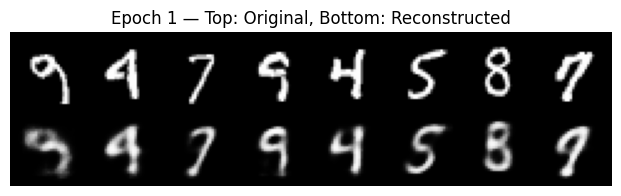

Epoch [2/10]  Avg Loss: 116.3906


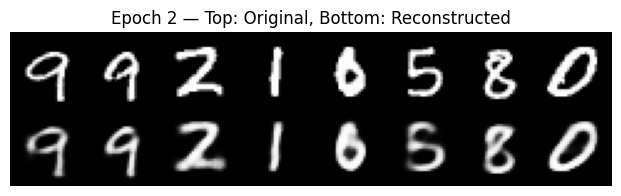

Epoch [3/10]  Avg Loss: 111.8836


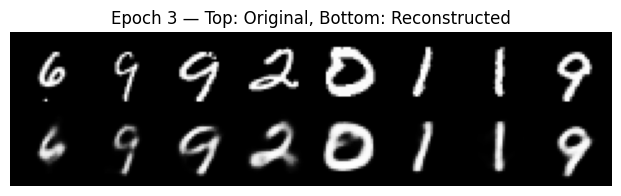

Epoch [4/10]  Avg Loss: 109.7948


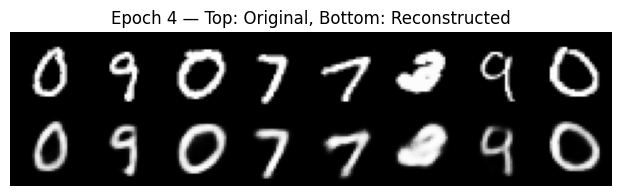

Epoch [5/10]  Avg Loss: 108.5142


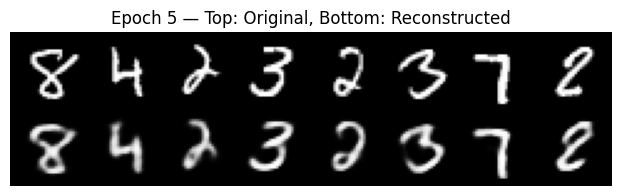

Epoch [6/10]  Avg Loss: 107.6293


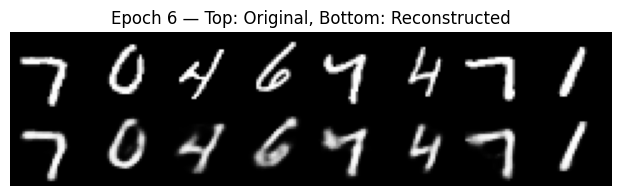

Epoch [7/10]  Avg Loss: 106.9938


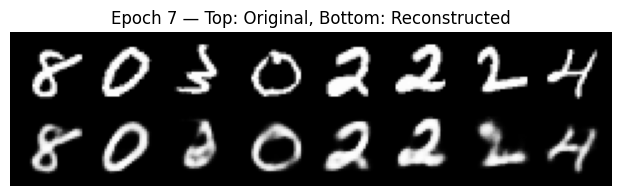

Epoch [8/10]  Avg Loss: 106.5353


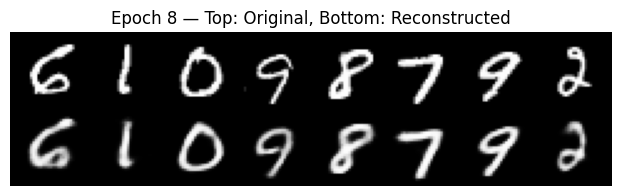

Epoch [9/10]  Avg Loss: 106.1533


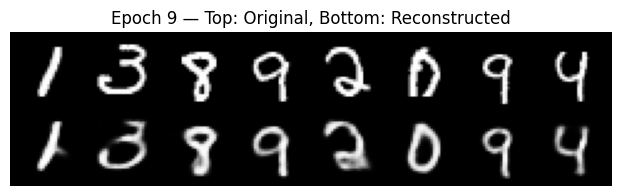

Epoch [10/10]  Avg Loss: 105.7824


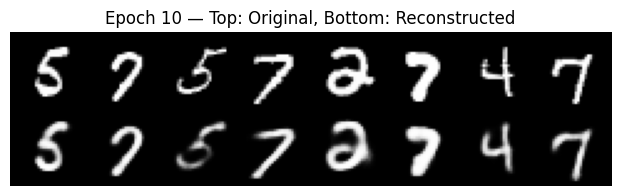

In [ ]:
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        data = data.view(data.size(0), -1)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{epochs}]  Avg Loss: {avg_loss:.4f}')

    model.eval()
    with torch.no_grad():
        sample_data, _ = next(iter(train_loader))
        sample_data = sample_data.to(device)
        sample_flat = sample_data.view(sample_data.size(0), -1)

        recon_batch, _, _ = model(sample_flat)
        recon_batch = recon_batch.view(-1, 1, 28, 28)

        comparison = torch.cat([sample_data[:8], recon_batch[:8]])

        grid = utils.make_grid(comparison.cpu(), nrow=8)
        plt.figure(figsize=(8, 2))
        plt.imshow(grid.permute(1, 2, 0).detach().numpy())
        plt.title(f"Epoch {epoch+1} — Top: Original, Bottom: Reconstructed")
        plt.axis('off')
        plt.show()